Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Image     : mouse
N_DEG     : 10  |  N_SAMPLES : 25  |  SCALE : 4x
Input size  : 168x168
Output size : 672x672
  ch 1/3  time=3.0s  range=[-46145.9, 16564.6]  clipped=3194
  ch 2/3  time=3.0s  range=[-46145.9, 16564.6]  clipped=3194
  ch 3/3  time=3.0s  range=[-46145.9, 16564.6]  clipped=3194

  Total time      : 9.0s
  MSE  vs bicubic : 7053.45
  PSNR vs bicubic : 9.65 dB
  Max  abs diff   : 46252.9


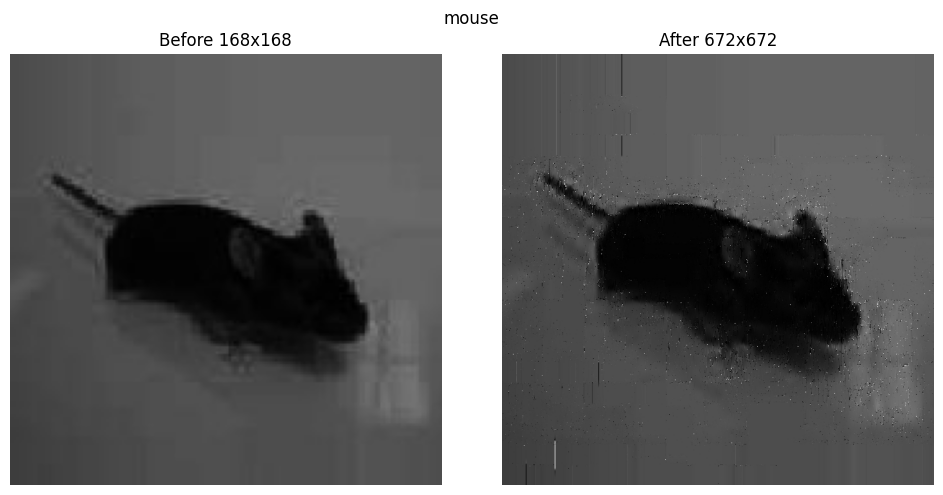


Image     : butterfly
N_DEG     : 10  |  N_SAMPLES : 25  |  SCALE : 4x
Input size  : 256x256
Output size : 1024x1024
  ch 1/3  time=7.3s  range=[-370876.0, 596997.9]  clipped=41131
  ch 2/3  time=7.3s  range=[-508560.9, 372211.3]  clipped=37402
  ch 3/3  time=7.2s  range=[-249889.2, 181003.9]  clipped=30534

  Total time      : 21.8s
  MSE  vs bicubic : 613058.08
  PSNR vs bicubic : -9.74 dB
  Max  abs diff   : 596934.9


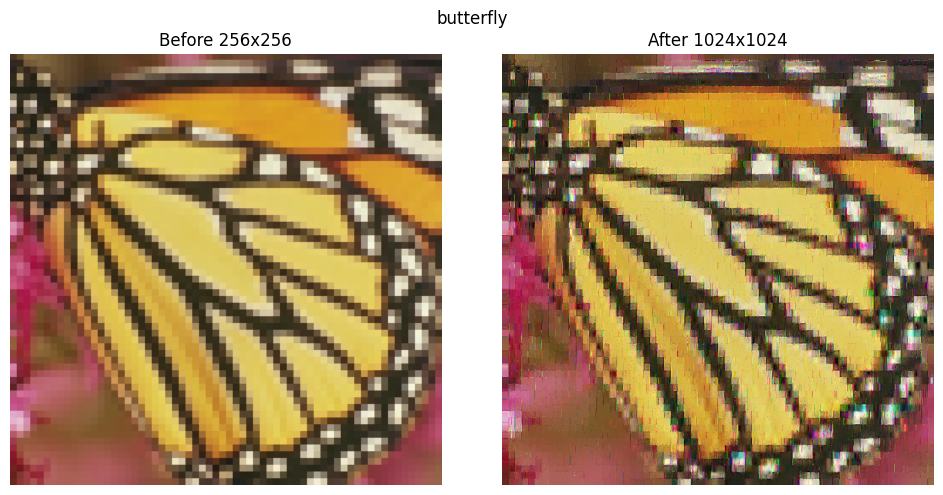


Image     : golf
N_DEG     : 10  |  N_SAMPLES : 25  |  SCALE : 4x
Input size  : 450x450
Output size : 1800x1800
  ch 1/3  time=29.2s  range=[-216707.2, 463663.9]  clipped=198156
  ch 2/3  time=28.8s  range=[-77509.8, 114775.5]  clipped=239777
  ch 3/3  time=28.9s  range=[-143984.1, 313742.9]  clipped=182653

  Total time      : 86.9s
  MSE  vs bicubic : 95456.08
  PSNR vs bicubic : -1.67 dB
  Max  abs diff   : 463449.9


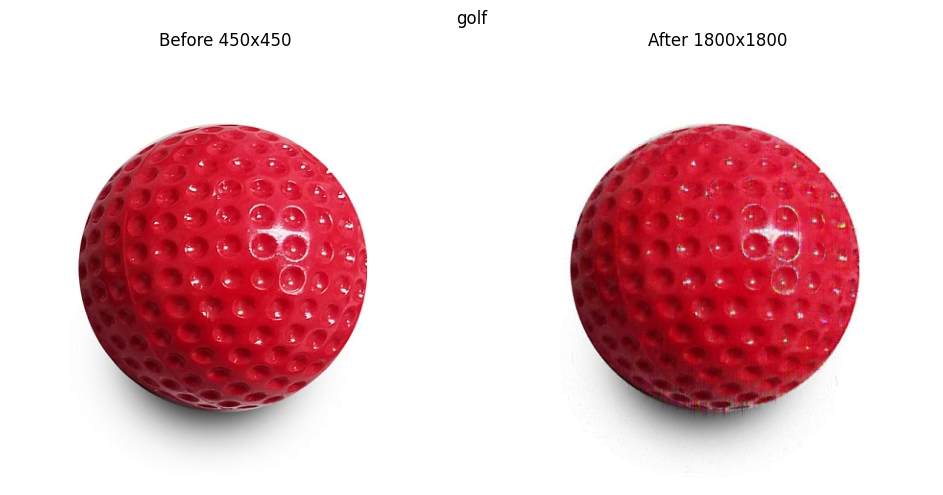

In [18]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import time
from google.colab import drive

drive.mount('/content/drive')

SCALE = 4
N_DEG  = 10
PATCH_SIZE = 25  # input pixels per patch
OVERLAP = 8    # overlap on each side between adjacent patches


# Rational fitting

def _eval_rational(coeffs, s, N):

    a = coeffs[:N+1]
    b = coeffs[N+1:]

    s_pow = np.array([s**j for j in range(N+1)])

    num = a @ s_pow
    den = b @ s_pow

    den = np.where(np.abs(den) < 1e-14, np.sign(den+1e-300)*1e-14, den)

    return num / den


def fit_rational_1d(x, y, N, x_eval):

    smax = float(np.max(np.abs(x))) if np.max(np.abs(x)) != 0 else 1.0
    s = x / smax
    se = x_eval / smax

    A = np.zeros((len(s), 2*N+2))

    for j in range(N+1):
        A[:,j] = -(s**j)
        A[:,N+1+j] = y*(s**j)

    _, sv, Vt = np.linalg.svd(A, full_matrices=True)

    sv_max = sv[0] if len(sv) > 0 else 1.0
    rank = int(np.sum(sv > 1e-10 * sv_max))

    n_cols = Vt.shape[0]

    if rank >= n_cols:
        ns = Vt[-1:].T
    else:
        ns = Vt[rank:].T

    n_cands = ns.shape[1]
    ysv = np.zeros((n_cands, len(x)))

    for j in range(n_cands):
        ysv[j] = _eval_rational(ns[:,j], s, N)

    mynorm = np.max(np.abs(ysv - y), axis=1)
    I = np.argmin(mynorm)

    return _eval_rational(ns[:,I], se, N)


# Image helpers

def _clamp(arr):
    return np.clip(np.round(arr), 0, 255).astype(np.uint8)


def _load_rgb(path):
    return np.array(Image.open(path).convert('RGB'), dtype=np.float32)


def _fit_1d_patch(x_full, y_full, N, x_dst_full, patch_size, overlap):
    # split x_full into overlapping patches, fit each, stitch with linear blend
    L    = len(x_full)
    step = patch_size - 2*overlap
    out  = np.zeros(len(x_dst_full), dtype=float)
    wsum = np.zeros(len(x_dst_full), dtype=float)

    p_start = 0
    while p_start < L:
        p_end = min(p_start + patch_size, L)
        px = x_full[p_start:p_end]
        py = y_full[p_start:p_end]

        # eval grid covering only this patch's x range
        dst_mask = (x_dst_full >= px[0]) & (x_dst_full <= px[-1])
        if dst_mask.sum() == 0 or len(px) < 3:
            p_start += step
            continue

        px_dst = x_dst_full[dst_mask]
        fitted = fit_rational_1d(px, py, N, px_dst)

        # triangular blend weight: 1 at patch centre, 0 at edges
        t = np.linspace(0, 1, dst_mask.sum())
        w = 1 - np.abs(2*t - 1)          # peaks at 0.5 → weight=1
        w = np.clip(w, 1e-6, 1)

        out[dst_mask]  += fitted * w
        wsum[dst_mask] += w

        if p_end == L:
            break
        p_start += step

    # anywhere not covered (shouldn't happen) just zero
    covered = wsum > 0
    out[covered] /= wsum[covered]
    return out


def _channel_upscale(ch, scale, N):

    H, W   = ch.shape
    W2, H2 = W*scale, H*scale

    x_src = np.arange(W, dtype=float)
    x_dst = np.linspace(0, W-1, W2)

    mid = np.zeros((H, W2), dtype=np.float32)

    for r in range(H):
        mid[r] = _fit_1d_patch(x_src, ch[r].astype(float), N, x_dst,
                               PATCH_SIZE, OVERLAP)

    y_src = np.arange(H, dtype=float)
    y_dst = np.linspace(0, H-1, H2)

    out = np.zeros((H2, W2), dtype=np.float32)

    for c in range(W2):
        out[:,c] = _fit_1d_patch(y_src, mid[:,c].astype(float), N, y_dst,
                                 PATCH_SIZE, OVERLAP)

    return out


def run_demo(image_path, label=None):

    tag = label if label else os.path.basename(image_path)
    print(f"\n{'='*55}")
    print(f"Image     : {tag}")
    print(f"N_DEG     : {N_DEG}  |  N_SAMPLES : {N_SAMPLES}  |  SCALE : {SCALE}x")
    print(f"{'='*55}")

    img = _load_rgb(image_path)
    H, W, _ = img.shape
    print(f"Input size  : {W}x{H}")
    print(f"Output size : {W*SCALE}x{H*SCALE}")

    t0 = time.time()
    channels = []

    for ch_i in range(3):
        tc = time.time()
        up = _channel_upscale(img[:,:,ch_i], SCALE, N_DEG)
        channels.append(up)
        ch_min, ch_max = up.min(), up.max()
        print(f"  ch {ch_i+1}/3  time={time.time()-tc:.1f}s  "
              f"range=[{ch_min:.1f}, {ch_max:.1f}]  "
              f"clipped={int(np.sum((up<0)|(up>255)))}")

    out_img = np.stack(channels, axis=2)
    total_time = time.time() - t0

    # stats vs bicubic
    bicubic = np.array(
        Image.open(image_path).convert('RGB').resize(
            (W*SCALE, H*SCALE), Image.BICUBIC
        ), dtype=float
    )
    diff = np.abs(out_img.astype(float) - bicubic)
    mse  = np.mean(diff**2)
    psnr = 10*np.log10(255**2/mse)
    print(f"\n  Total time      : {total_time:.1f}s")
    print(f"  MSE  vs bicubic : {mse:.2f}")
    print(f"  PSNR vs bicubic : {psnr:.2f} dB")
    print(f"  Max  abs diff   : {diff.max():.1f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(tag)
    axes[0].imshow(_clamp(img))
    axes[0].set_title(f"Before {W}x{H}")
    axes[0].axis("off")
    axes[1].imshow(_clamp(out_img))
    axes[1].set_title(f"After {W*SCALE}x{H*SCALE}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()




run_demo("/content/drive/MyDrive/mouse.jpg",     label="mouse")
run_demo("/content/drive/MyDrive/butter.png", label="butterfly")
run_demo("/content/drive/MyDrive/golf.jpg", label="golf")